In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
from datetime import datetime, timedelta
import torchvision.models as models
from torchvision.models import VGG16_Weights
from tqdm import tqdm
from matplotlib.ticker import AutoMinorLocator
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgp_utils import *
from python_scripts.plotting import *
from python_scripts.math_utils import *
from python_scripts.preprocessing import *
from scipy.special import gammaln
import warnings
warnings.filterwarnings("ignore")

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


#### <font color='yellow'> Example of simulated sgp dataset with beta distributions mixture

In [2]:
df = simulate_sgp_dataset(n=10000)
df

,y_true,y_pred,kappa
0,0,0.0,0.994084
1,1,1.0,0.972204
2,0,0.0,0.763839
3,0,0.0,0.977806
4,0,1.0,0.380255
...,...,...,...
9995,1,1.0,0.837544
9996,0,0.0,0.956362
9997,1,1.0,0.758735
9998,1,1.0,0.819119


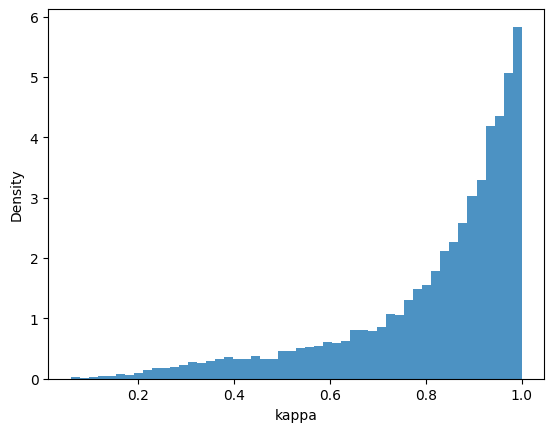

In [3]:
plt.hist(df['kappa'], bins=50, density=True, alpha=0.8)
plt.xlabel("kappa")
plt.ylabel("Density")
plt.show()

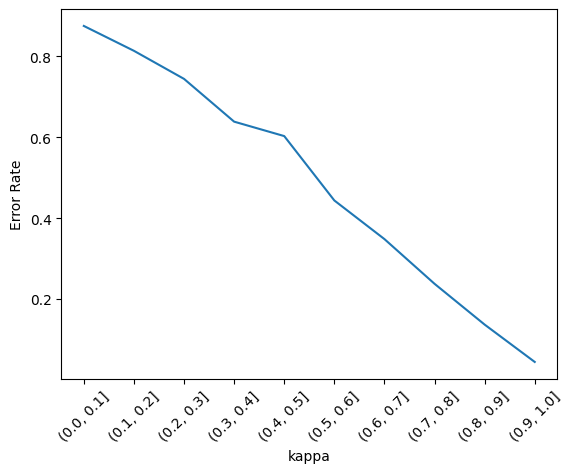

In [4]:
mistakes_by_SR = df.groupby(pd.cut(df['kappa'], bins=np.linspace(0, 1, 11)))['y_true'].apply(lambda x: (x != df.loc[x.index, 'y_pred']).mean())
plt.plot(mistakes_by_SR.index.astype(str), mistakes_by_SR)
plt.xlabel("kappa")
plt.ylabel("Error Rate")
plt.xticks(rotation=45)
plt.show()

#### <font color='yellow'> Evolution of runtime with sample size n

In [5]:
n_seed = 20
samples_sizes = [10000*i for i in range(1,11)]

In [ ]:
dicos = []

for n in samples_sizes:
    times = [runtime(simulate_sgp_dataset(n=n, seed=seed)) for seed in range(n_seed)]
    quantiles = [np.quantile(times, q=q) for q in [0.25, 0.5, 0.75]]
    dicos.append({'Search mode' : 'Dichotomy', 'n' : n, 'Runtime quantiles' : quantiles})

    for steps in [30, 50, 100]:
        times = [runtime(simulate_sgp_dataset(n=n, seed=seed), mode='greedy', greedy_steps=steps) for seed in range(n_seed)]
        quantiles = [np.quantile(times, q=q) for q in [0.25, 0.5, 0.75]]
        dicos.append({'Search mode': 'Greedy_'+str(steps)+'_steps', 'n': n, 'Runtime quantiles' : quantiles})

In [ ]:
times = pd.DataFrame(dicos)
times

,Search mode,n,Runtime quantiles
0,Dichotomy,10000,"[0.0, 0.0, 0.25]"
1,Greedy_10_steps,10000,"[1.0, 1.0, 1.0]"
2,Greedy_20_steps,10000,"[3.0, 3.0, 3.0]"
3,Greedy_50_steps,10000,"[8.0, 23.0, 25.0]"
4,Dichotomy,20000,"[5.0, 6.0, 7.0]"
5,Greedy_10_steps,20000,"[3.0, 3.0, 10.0]"
6,Greedy_20_steps,20000,"[6.0, 7.0, 7.0]"
7,Greedy_50_steps,20000,"[17.0, 17.0, 17.0]"
8,Dichotomy,30000,"[2.0, 2.0, 3.0]"
9,Greedy_10_steps,30000,"[5.0, 5.0, 5.0]"


In [ ]:
pickle.dump(times, open('exec_times_res','wb'))

In [ ]:
times =  pickle.load(open('exec_times_res','rb'))

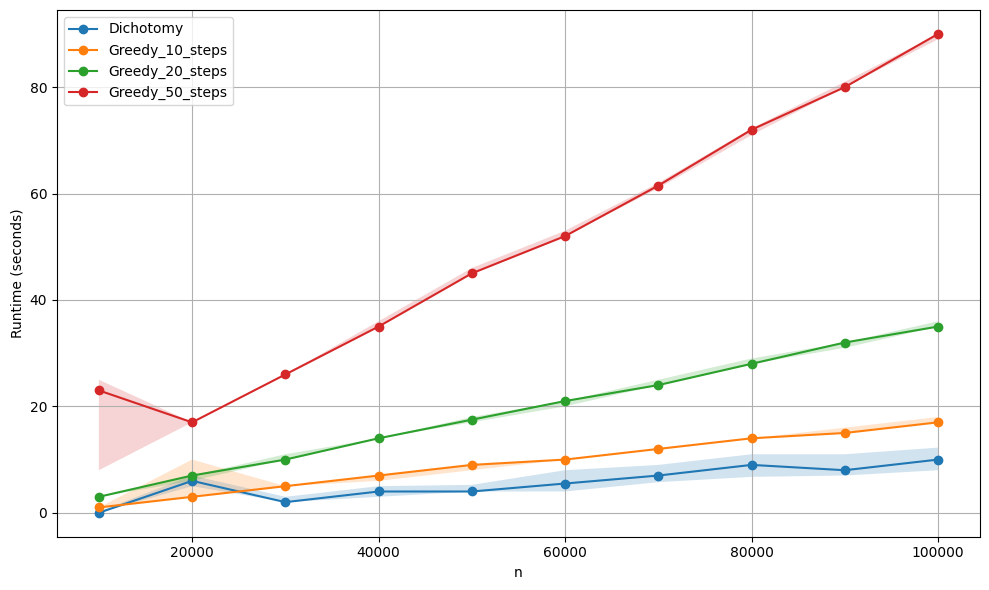

In [ ]:
# --- STYLE ONLY (logic unchanged) ----------------------------------
rc = {
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "legend.facecolor": "white",
    "legend.edgecolor": "#D0D0D0",
    "grid.alpha": 0.4,
    "lines.linewidth": 2.0,
}
with plt.rc_context(rc), plt.style.context("seaborn-v0_8-whitegrid"):
    fig, ax = plt.subplots(figsize=(7, 4))

    # --- Original plotting logic ---
    for mode, group in times.groupby("Search mode"):
        group = group.sort_values("n")
        ax.plot(group["n"], group["median"], label=mode,
                marker="o", markersize=5, linewidth=2)
        ax.fill_between(group["n"], group["q1"], group["q3"], alpha=0.2)

    # Labels and legend
    ax.set_xlabel("n")
    ax.set_ylabel("Runtime (seconds)")
    ax.legend(loc="best", fontsize=10)

    # Spines, ticks, grid
    for spine in ax.spines.values():
        spine.set_color("#B0B0B0")
        spine.set_linewidth(0.9)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.3)

    plt.tight_layout()
    plt.show()